In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Exploration

In [ ]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


Column----------------------------Meaning

gender----------------------------Mard ya aurat 

age-------------------------------Age is an important factor as diabetes is more commonly diagnosed in older adults.Age ranges from

Umarhypertension------------------BP ki problem hai ya nahi (0/1) 

heart_disease---------------------Dil ki bimari hai ya nahi (0/1) (Heart disease is another medical condition that is associated with an increased risk of developing diabetes. I)

smoking_history-------------------Cigarette peeta/nahi peeta hai? (Smoking history is also considered a risk factor for diabetes and can exacerbate the complications associated)

bmi-------------------------------Motapa ka number (BMI (Body Mass Index) is a measure of body fat based on weight and height. Higher BMI values are linked to an increased risk of diabetes, as excess body fat can lead to insulin resistance.)

HbA1c_level-----------------------Blood sugar ka 3 mahine ka average

blood_glucose_level---------------Abhi ka blood sugar

diabetes--------------------------Target — 0 = nahi hai, 1 = hai ✅

In [ ]:
df.shape

(100000, 9)

In [ ]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')

# 3. Data Cleaning

In [ ]:
df.dtypes

gender                     str
age                    float64
hypertension             int64
heart_disease            int64
smoking_history            str
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

All the columns right now in the correct datatype

In [ ]:
# Null values
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

NO null values in the dataset, so no need to handle missing data.

In [ ]:
# Duplicated values
df.duplicated().sum()

np.int64(3854)

In [ ]:
# Drop duplicates
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')

In [ ]:
df['smoking_history'].value_counts()

smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64

In [ ]:
#impotant feature
#pd.get_dummies(df, drop_first=True)

In [ ]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


# 4. Descriptive Analysis

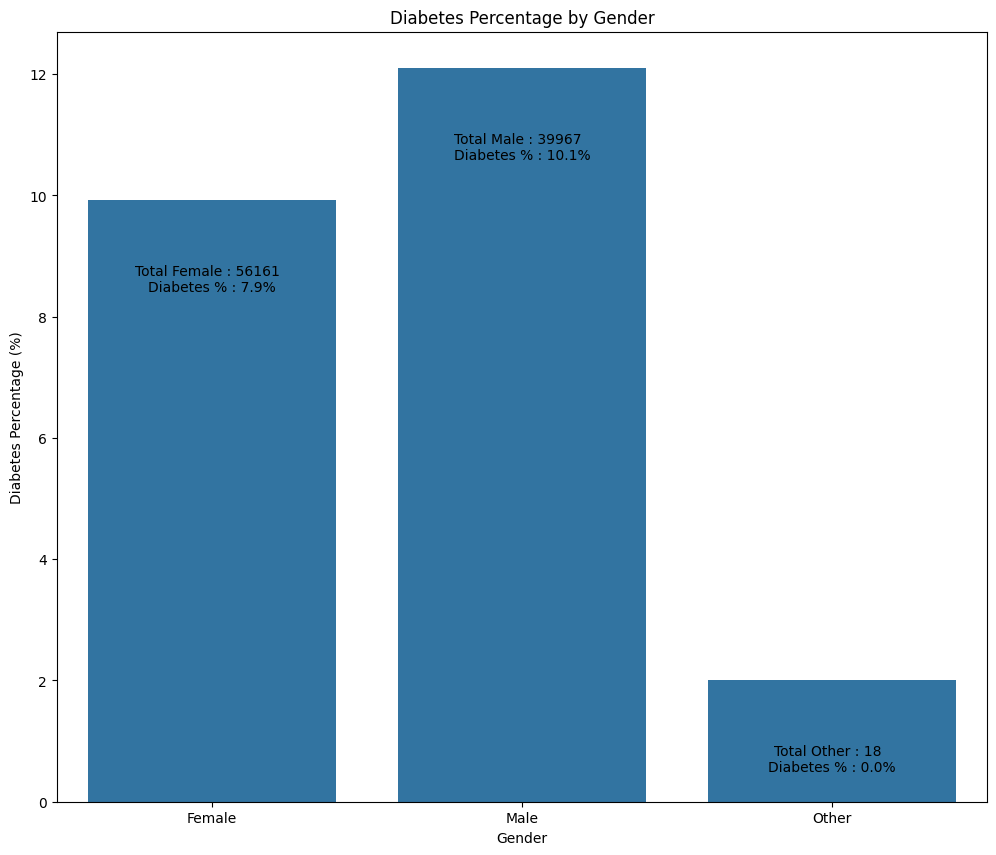

In [ ]:
# Gender wise total
gender_count = df['gender'].value_counts()

# Gender wise diabetes percentage
diabetes_percent = df.groupby('gender')['diabetes'].mean() * 100

#Figure size
plt.figure(figsize=(12,10))

#Bar plot 
ax = sns.barplot(
    x = diabetes_percent.index,
    y = diabetes_percent.values + 2
)

# add count + % on top of bars
for i ,gender in enumerate(diabetes_percent.index):
    count = gender_count[gender]
    percent = diabetes_percent[gender]


    ax.text(i,percent + 0.5,f"Total {gender} : {count}  \nDiabetes % : {percent:.1f}%",ha = 'center')
    

    # Labels
plt.title('Diabetes Percentage by Gender')
plt.xlabel('Gender')
plt.ylabel('Diabetes Percentage (%)')

plt.show()

Insites:

Higher Prevalence in Males: Even though the male sample size is smaller, males show a higher diabetes rate (10.1%) compared to females (7.9%).

Sample Imbalance: The dataset is skewed toward female participants (56,161 females vs. 39,967 males), but the percentage-based analysis confirms a stronger trend of diabetes among male subjects

In [ ]:
# Removing 'Other' gender category due to extreme data imbalance (only 18 samples) 
# and a 0% diabetes rate, which could introduce bias into the ML model.
df = df[df['gender'] != 'Other']
print(df['gender'].value_counts())

gender
Female    56161
Male      39967
Name: count, dtype: int64


In [ ]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


good BMI range: 18.5% to 24.9%
Healthy hemoglobin levels generally range from 13.5 to 17.5 grams per deciliter (g/dL) for adult men and 12.0 to 15.5 g/dL for adult women
Healthy, normal blood glucose (sugar) levels typically range from 70 to 99 mg/dL while fasting and under 140 mg/dL two hours after a meal.

In [ ]:
df.groupby('smoking_history').agg( total_count = ('diabetes', 'count'),mean_diabetes = ('diabetes', 'mean')).round(2).reset_index()

,smoking_history,total_count,mean_diabetes
0,No Info,32881,0.04
1,current,9197,0.10
2,ever,3997,0.12
3,former,9299,0.17
4,never,34395,0.10
5,not current,6359,0.11


--- Grouped Data Summary ---
  smoking_history  Total_Count  Diabetes_Count  Diabetes_Percentage
0         No Info        10750            1216            11.311628
1         current         3156             765            24.239544
2            ever         1389             378            27.213823
3          former         3743            1321            35.292546
4           never        11413            2756            24.147902
5     not current         2314             573            24.762316


C:\Users\irfan khan\AppData\Local\Temp\ipykernel_11376\2390997295.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='smoking_history', y='Diabetes_Percentage', data=grouped_data, palette='magma')


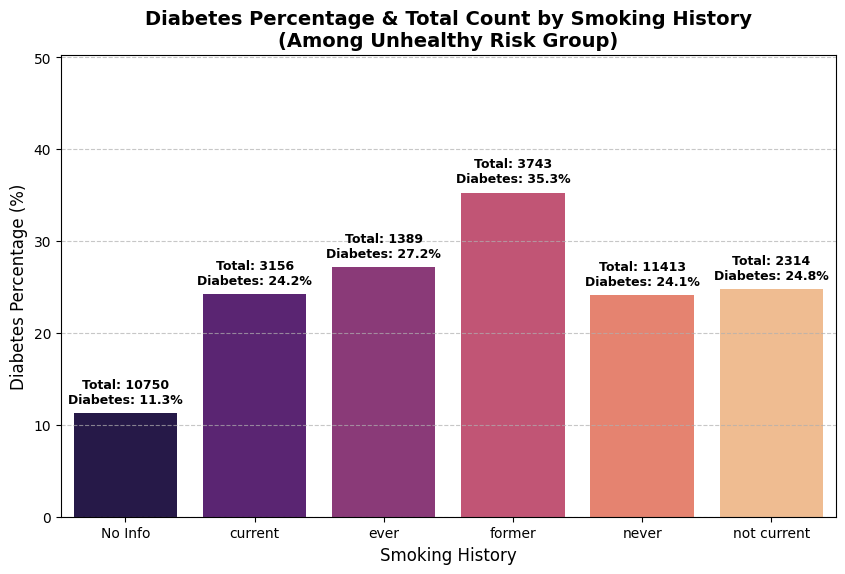

In [ ]:
# 1. Sabhi bad health metrics ka filter lagana
bad_bmi = (df['bmi'] < 18.5) | (df['bmi'] > 24.9)
bad_glucose = df['blood_glucose_level'] > 99
bad_hb = df['HbA1c_level'] > 5.7

# Unhealthy logon ka dataframe banana
unhealthy_df = df[bad_bmi & bad_glucose & bad_hb]

# 2. Smoking history ke hisab se Grouping karna (Count aur Diabetes % nikalna)
grouped_data = unhealthy_df.groupby('smoking_history').agg(
    Total_Count=('diabetes', 'count'),
    Diabetes_Count=('diabetes', 'sum')
).reset_index()

# Diabetes percentage calculate karna
grouped_data['Diabetes_Percentage'] = (grouped_data['Diabetes_Count'] / grouped_data['Total_Count']) * 100

print("--- Grouped Data Summary ---")
print(grouped_data)

# 3. Bar Plot banana (Diabetes % by Smoking History)
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='smoking_history', y='Diabetes_Percentage', data=grouped_data, palette='magma')

# Bars ke upar text tags lagana (Total Count aur Diabetes % dono dikhane ke liye)
for i, p in enumerate(ax.patches):
    count = grouped_data.loc[i, 'Total_Count']
    percentage = grouped_data.loc[i, 'Diabetes_Percentage']


    ax.annotate(f'Total: {count}\nDiabetes: {percentage:.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 15), 
                textcoords='offset points',
                fontsize=9, fontweight='bold')

plt.title('Diabetes Percentage & Total Count by Smoking History\n(Among Unhealthy Risk Group)', fontsize=14, fontweight='bold')
plt.xlabel('Smoking History', fontsize=12)
plt.ylabel('Diabetes Percentage (%)', fontsize=12)
plt.ylim(0, grouped_data['Diabetes_Percentage'].max() + 15) # Top par space dene ke liye
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

INSIGHTS: 

Insight: Former smokers exhibit the highest diabetes risk (35.29%) 
compared to all other smoking history categories in the unhealthy risk group.


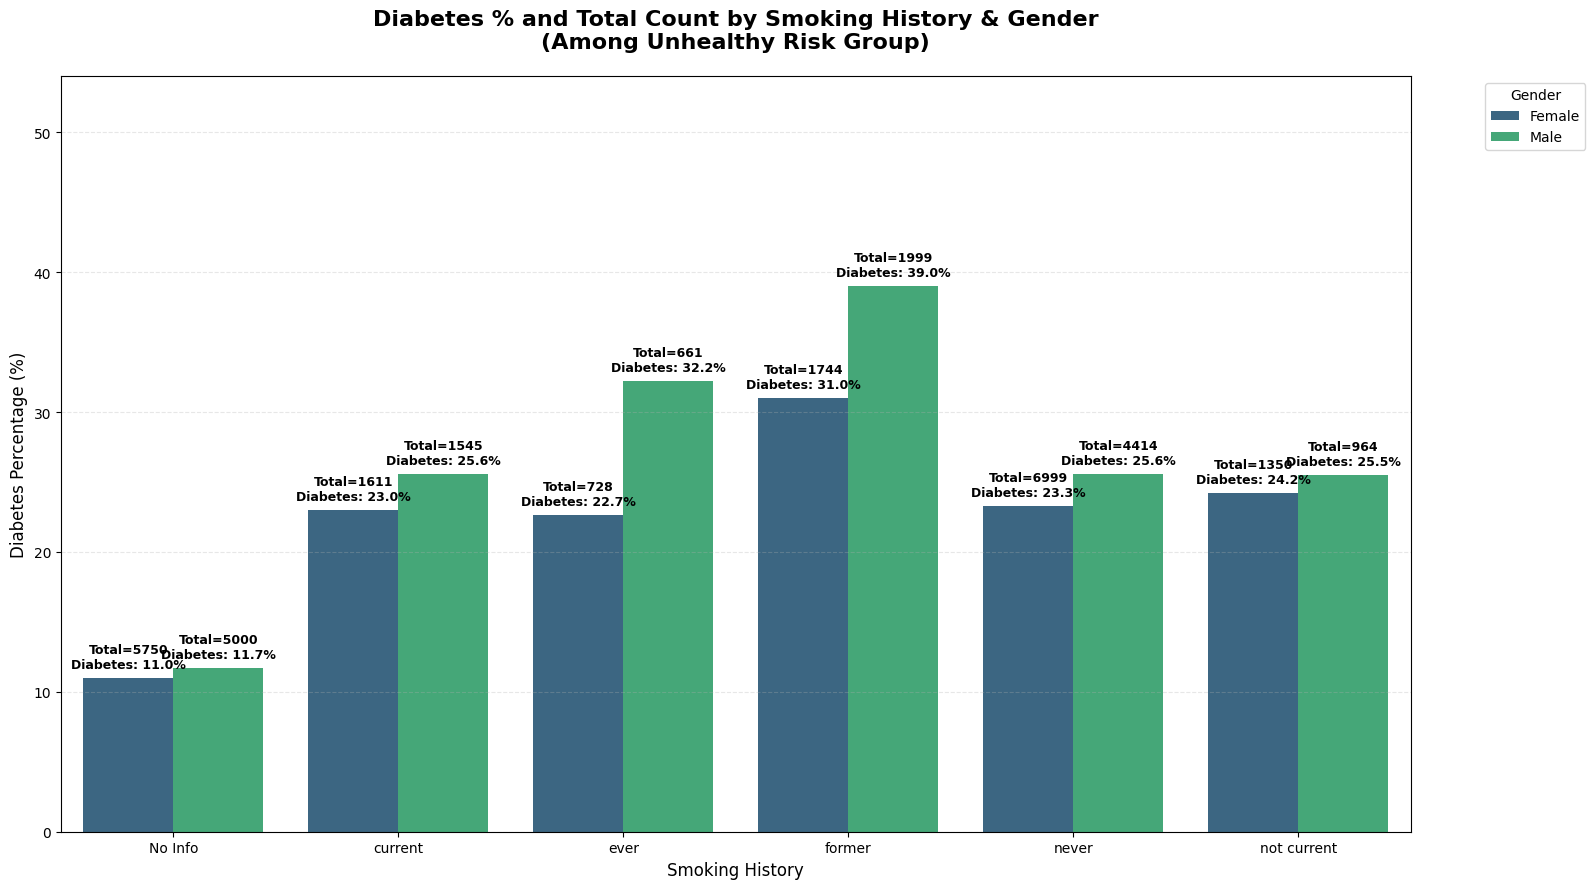

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filters (Same as your logic)
bad_bmi = (df['bmi'] < 18.5) | (df['bmi'] > 24.9)
bad_glucose = df['blood_glucose_level'] > 99
bad_hb = df['HbA1c_level'] > 5.7

unhealthy_df = df[bad_bmi & bad_glucose & bad_hb]

# 2. Grouping by Smoking History and Gender
# Humein ensure karna hoga ki data sorted ho taaki bars aur labels align rahein
combined_data = unhealthy_df.groupby(['smoking_history', 'gender']).agg(
    Total_Count=('diabetes', 'count'),
    Diabetes_Count=('diabetes', 'sum')
).reset_index()

combined_data['Diabetes_Percentage'] = (combined_data['Diabetes_Count'] / combined_data['Total_Count']) * 100

# Plotting ke liye categories ko sort kar lete hain
combined_data = combined_data.sort_values(['smoking_history', 'gender'])

# 3. Visualization
plt.figure(figsize=(16, 9))
ax = sns.barplot(
    x='smoking_history', 
    y='Diabetes_Percentage', 
    hue='gender', 
    data=combined_data, 
    palette='viridis'
)

# 4. Labels add karne ka logic (Total Count + Percentage)
# Har container ek specific gender (hue) ko represent karta hai
for i, container in enumerate(ax.containers):
    # Legend se current gender ka naam nikalte hain
    gender_name = ax.get_legend_handles_labels()[1][i]
    
    # Is gender ke liye data filter karte hain taaki counts match ho sakein
    gender_subset = combined_data[combined_data['gender'] == gender_name]
    
    # Har bar ke upar text likhna
    for bar, (_, row) in zip(container, gender_subset.iterrows()):
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'Total={int(row["Total_Count"])}\nDiabetes: {height:.1f}%', 
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 5), # 5 points offset upar ki taraf
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=9, fontweight='bold', color='black')

plt.title('Diabetes % and Total Count by Smoking History & Gender\n(Among Unhealthy Risk Group)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Smoking History', fontsize=12)
plt.ylabel('Diabetes Percentage (%)', fontsize=12)

# Y-axis limit ko thoda badhana taaki labels kat na jayein
plt.ylim(0, combined_data['Diabetes_Percentage'].max() + 15)

plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()



insites : 

High Prevalence across all categories : Within this unhealthy risk group, regardless of smoking history ('never', 'current', or 'not current'), the prevalence of diabetes is quite high (ranging between 23% and 25%) and roughly equal for both males and females.

Former and Ever Smokers (The Exception) : The 'former' and 'ever' categories are the only ones where the percentage of diabetes is significantly higher in males compared to females (for instance, 39.0% for males versus 31.0% for females in the 'former' category).

Other Risk Factors: This suggests that within this particular group, factors other than smoking—such as high BMI, age, or blood glucose levels—play a more significant role in increasing the risk of diabetes for both genders.

In [ ]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


--- Grouped Data Summary ---
  smoking_history  Total_Count  Diabetes_Count  Diabetes_Percentage
0         No Info         3056               0                  0.0
1         current          801               0                  0.0
2            ever          354               0                  0.0
3          former          735               0                  0.0
4           never         2907               0                  0.0
5     not current          542               0                  0.0


C:\Users\irfan khan\AppData\Local\Temp\ipykernel_11376\1909523245.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='smoking_history', y='Diabetes_Percentage', data=grouped_data, palette='magma')


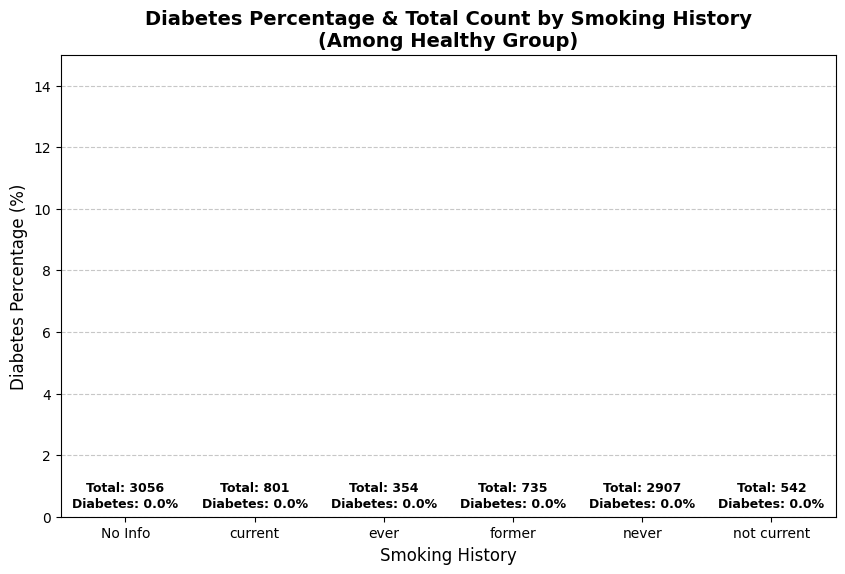

In [ ]:
# 1. Sabhi good health metrics ka filter lagana
good_bmi = (df['bmi'] > 18.5) | (df['bmi'] < 24.9)
good_glucose = df['blood_glucose_level'] < 99
good_hb = df['HbA1c_level'] < 5.7

# healthy logon ka dataframe banana
healthy_df = df[good_bmi & good_glucose & good_hb]

# 2. Smoking history ke hisab se Grouping karna (Count aur Diabetes % nikalna)
grouped_data = healthy_df.groupby('smoking_history').agg(
    Total_Count=('diabetes', 'count'),
    Diabetes_Count=('diabetes', 'sum')
).reset_index()

# Diabetes percentage calculate karna
grouped_data['Diabetes_Percentage'] = (grouped_data['Diabetes_Count'] / grouped_data['Total_Count']) * 100

print("--- Grouped Data Summary ---")
print(grouped_data)

# 3. Bar Plot banana (Diabetes % by Smoking History)
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='smoking_history', y='Diabetes_Percentage', data=grouped_data, palette='magma')

# Bars ke upar text tags lagana (Total Count aur Diabetes % dono dikhane ke liye)
for i, p in enumerate(ax.patches):
    count = grouped_data.loc[i, 'Total_Count']
    percentage = grouped_data.loc[i, 'Diabetes_Percentage']


    ax.annotate(f'Total: {count}\nDiabetes: {percentage:.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 15), 
                textcoords='offset points',
                fontsize=9, fontweight='bold')

plt.title('Diabetes Percentage & Total Count by Smoking History\n(Among Healthy Group)', fontsize=14, fontweight='bold')
plt.xlabel('Smoking History', fontsize=12)
plt.ylabel('Diabetes Percentage (%)', fontsize=12)
plt.ylim(0, grouped_data['Diabetes_Percentage'].max() + 15) # Top par space dene ke liye
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Insites :

Isolation of Risk Factors: When filtering for the "Healthy Group" (Normal BMI between 18.5–24.9, Normal Fasting Blood Glucose < 99 mg/dL, and Normal HbA1c < 5.7%), the diabetes prevalence drops sharply to 0% across all smoking categories (including current and former smokers).

Conclusion: This strongly indicates that smoking does not directly cause diabetes in isolation. Instead, it acts as a compounding risk factor that exacerbates insulin resistance primarily when combined with other metabolic vulnerabilities like obesity (high BMI) or elevated glucose levels.

--- Grouped Data Summary ---
  smoking_history  Total_Count  Diabetes_Count  Diabetes_Percentage
0         No Info         2603               7             0.268920
1         current          777               7             0.900901
2            ever          353               8             2.266289
3          former          593              13             2.192243
4           never         3274              30             0.916310
5     not current          458               3             0.655022


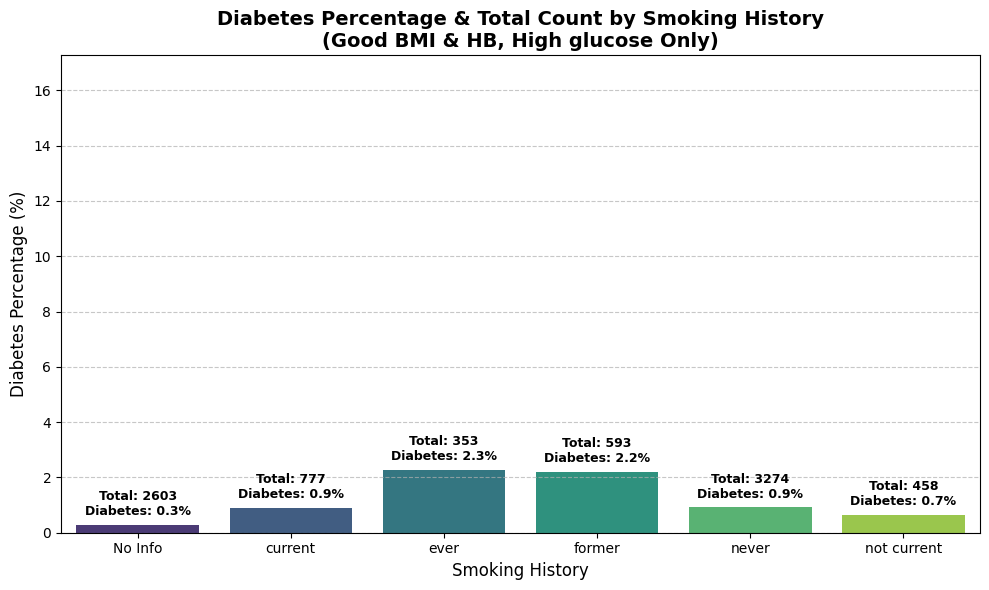

In [ ]:


# 1. Filters - Sirf glucose and BMI unhealthy, BMI aur Glucose NORMAL/GOOD range mein
good_bmi = (df['bmi'] >= 18.5) & (df['bmi'] <= 24.9)        # ✅ Normal BMI range
bad_glucose = df['blood_glucose_level'] > 99                #    unhealthy glucose
good_hb = df['HbA1c_level'] <= 5.7                           # ✅ Normal HB

# Aise log jinka sirf HbA1c kharab hai, baaki sab theek
filtered_df = df[good_bmi & bad_glucose & good_hb]

# 2. Grouping
grouped_data = filtered_df.groupby('smoking_history').agg(
    Total_Count=('diabetes', 'count'),
    Diabetes_Count=('diabetes', 'sum')
).reset_index()

grouped_data['Diabetes_Percentage'] = (
    grouped_data['Diabetes_Count'] / grouped_data['Total_Count']
) * 100

print("--- Grouped Data Summary ---")
print(grouped_data)

# 3. Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='smoking_history',
    y='Diabetes_Percentage',
    data=grouped_data,
    palette='viridis',
    hue='smoking_history',  # ✅ Deprecation warning fix
    legend=False
)

for i, p in enumerate(ax.patches):
    count = grouped_data.loc[i, 'Total_Count']
    percentage = grouped_data.loc[i, 'Diabetes_Percentage']
    ax.annotate(
        f'Total: {count}\nDiabetes: {percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 15),
        textcoords='offset points',
        fontsize=9, fontweight='bold'
    )

plt.title(
    'Diabetes Percentage & Total Count by Smoking History\n(Good BMI & HB, High glucose Only)',
    fontsize=14, fontweight='bold'
)
plt.xlabel('Smoking History', fontsize=12)
plt.ylabel('Diabetes Percentage (%)', fontsize=12)
plt.ylim(0, grouped_data['Diabetes_Percentage'].max() + 15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insight:

When only blood glucose is elevated (BMI & HbA1c normal), diabetes rate is extremely low — just 0.3% to 2.3% across all smoking groups.

This is because a glucose spike can be temporary — caused by stress, food, or exercise. But when HbA1c rises alongside glucose, diabetes risk jumps to 18–35%.

Bottom line: Glucose alone is not a reliable diabetes indicator. HbA1c is the real deciding factor

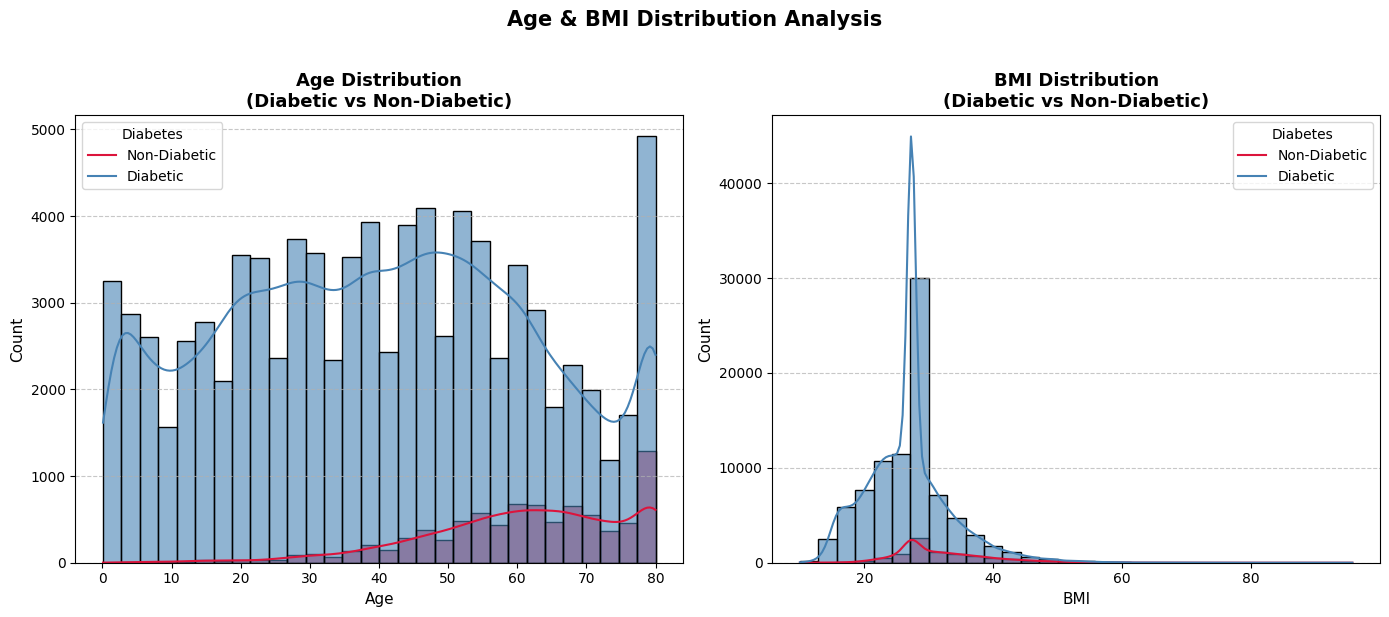

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Age Distribution ---
sns.histplot(
    data=df, x='age', hue='diabetes',
    kde=True, bins=30,
    palette={0: 'steelblue', 1: 'crimson'},
    alpha=0.6, ax=axes[0]
)
axes[0].set_title('Age Distribution\n(Diabetic vs Non-Diabetic)', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(labels=['Non-Diabetic', 'Diabetic'], title='Diabetes')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: BMI Distribution ---
sns.histplot(
    data=df, x='bmi', hue='diabetes',
    kde=True, bins=30,
    palette={0: 'steelblue', 1: 'crimson'},
    alpha=0.6, ax=axes[1]
)
axes[1].set_title('BMI Distribution\n(Diabetic vs Non-Diabetic)', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('BMI', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(labels=['Non-Diabetic', 'Diabetic'], title='Diabetes')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Age & BMI Distribution Analysis', 
              fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Key Insight: The exploratory data analysis reveals that both Age and BMI are strong predictors for diabetes. We observe a significant upward trend in diabetic cases within the 50–80 age bracket. Additionally, the diabetic distribution is noticeably shifted toward higher BMI values ($>25$), highlighting obesity as a critical risk factor. However, a prominent class imbalance exists, as non-diabetic records heavily outnumber diabetic ones, which we must address during model training.

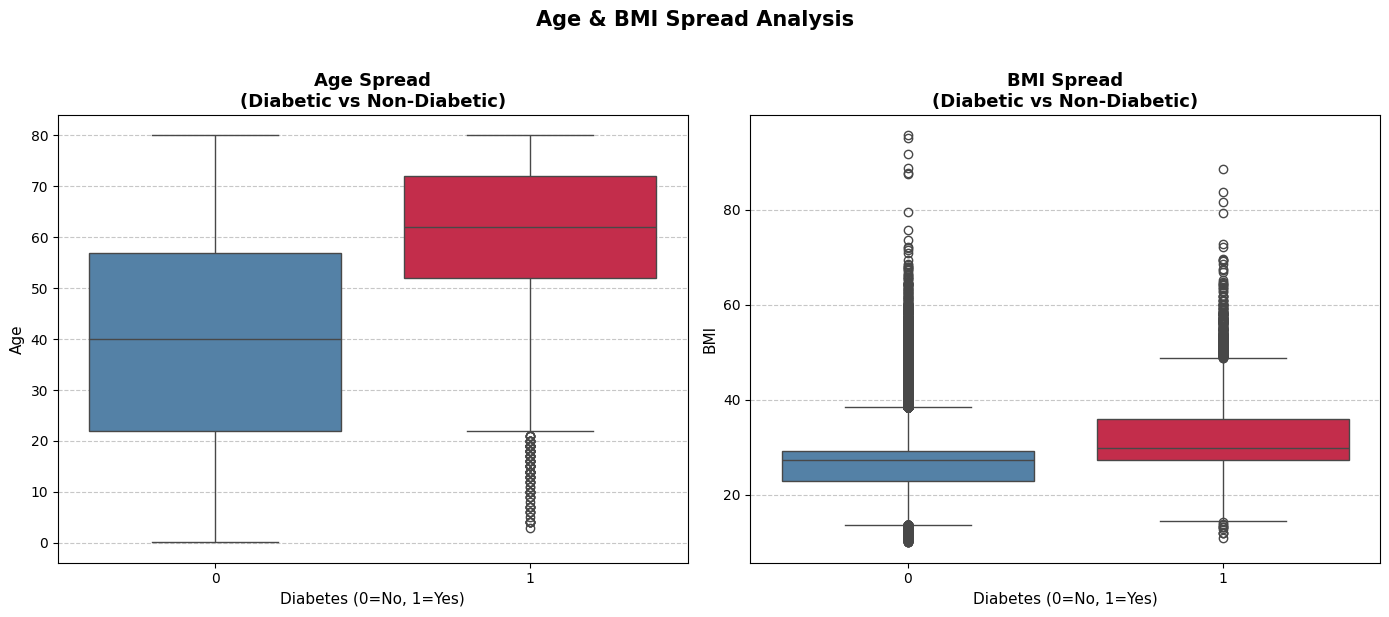

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Fix: Use integers as keys because your data contains np.int64 values
diabetes_palette = {0: 'steelblue', 1: 'crimson'}

# --- Box Plot 1: Age ---
sns.boxplot(
    data=df, 
    x='diabetes', 
    y='age',
    hue='diabetes',            # Assigning hue ensures the palette maps correctly
    palette=diabetes_palette,
    legend=False,              # Set to False since x-axis labels are sufficient
    ax=axes[0]
)
axes[0].set_title('Age Spread\n(Diabetic vs Non-Diabetic)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Diabetes (0=No, 1=Yes)', fontsize=11)
axes[0].set_ylabel('Age', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Box Plot 2: BMI ---
sns.boxplot(
    data=df, 
    x='diabetes', 
    y='bmi',
    hue='diabetes',
    palette=diabetes_palette,
    legend=False,
    ax=axes[1]
)
axes[1].set_title('BMI Spread\n(Diabetic vs Non-Diabetic)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Diabetes (0=No, 1=Yes)', fontsize=11)
axes[1].set_ylabel('BMI', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Age & BMI Spread Analysis', 
              fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Key Insight: The spread analysis confirms a distinct variation in both features based on diabetes status. The median age for diabetic individuals is significantly higher (~60 years) compared to non-diabetics (~40 years). While diabetic individuals show a higher median BMI overall, both target classes exhibit a heavy presence of extreme BMI outliers extending up to 80–90. These extreme values require careful capping or transformation before feeding the data into distance-based machine learning models.

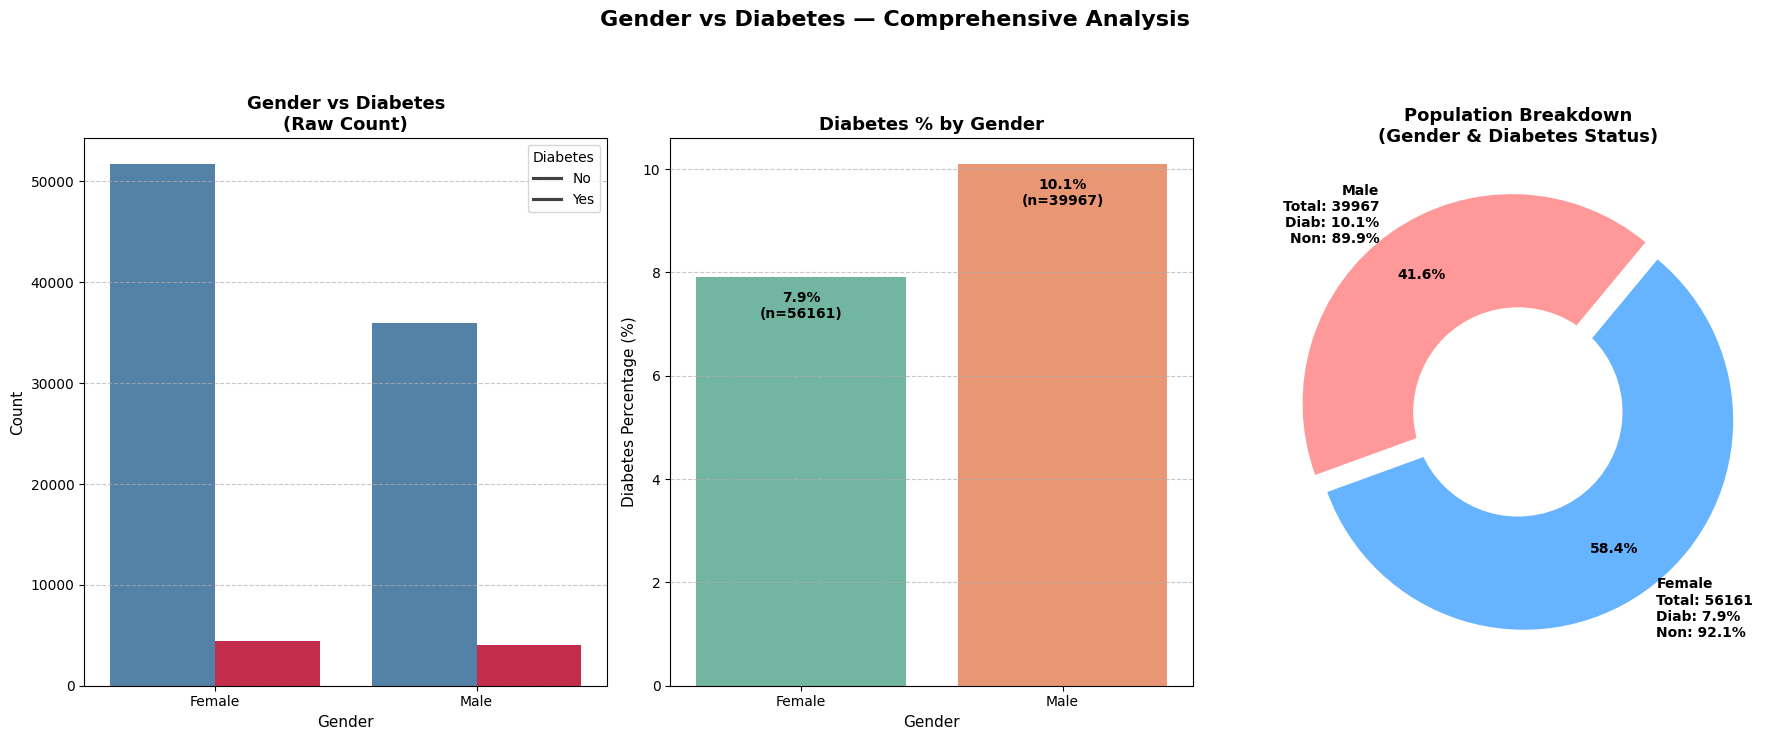

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# --- Plot 1: Count Plot ---
gender_data = df.groupby(['gender', 'diabetes']).size().reset_index(name='count')
sns.barplot(
    data=gender_data, x='gender', y='count',
    hue='diabetes',
    palette={0: 'steelblue', 1: 'crimson'},
    ax=axes[0]
)
axes[0].set_title('Gender vs Diabetes\n(Raw Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(title='Diabetes', labels=['No', 'Yes'])
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: Percentage Bar Plot ---
gender_pct = df.groupby('gender')['diabetes'].agg(['sum', 'count']).reset_index()
gender_pct['Diabetes_%'] = (gender_pct['sum'] / gender_pct['count']) * 100

sns.barplot(
    data=gender_pct, x='gender', y='Diabetes_%',
    hue='gender',
    palette='Set2',
    ax=axes[1],
    legend=False
)
for i, p in enumerate(axes[1].patches):
    pct = gender_pct.loc[i, 'Diabetes_%']
    total = gender_pct.loc[i, 'count']
    axes[1].annotate(
        f'{pct:.1f}%\n(n={total})',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='top', 
        xytext=(0, -10),
        textcoords='offset points',
        fontsize=10, fontweight='bold'
    )
axes[1].set_title('Diabetes % by Gender', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=11)
axes[1].set_ylabel('Diabetes Percentage (%)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 3: Enhanced Pie Chart (Donut Style) ---
# यहाँ हमने डेटा तैयार किया है ताकि लेबल में सब कुछ दिख सके
pie_labels = []
for idx, row in gender_pct.iterrows():
    total_n = int(row['count'])
    diab_n = int(row['sum'])
    diab_p = (diab_n / total_n) * 100
    non_diab_p = 100 - diab_p
    
    # लेबल में: Gender, Total Count, Diabetic %, Non-Diabetic %
    label = (f"{row['gender']}\n"
             f"Total: {total_n}\n"
             f"Diab: {diab_p:.1f}%\n"
             f"Non: {non_diab_p:.1f}%")
    pie_labels.append(label)

# पाई चार्ट बनाना (कुल जेंडर डिस्ट्रीब्यूशन पर आधारित)
wedges, texts, autotexts = axes[2].pie(
    gender_pct['count'], 
    labels=pie_labels,
    autopct='%1.1f%%',
    startangle=200,
    colors=['#66b3ff','#ff9999','#99ff99'],
    pctdistance=0.75,
    explode=[0.05] * len(gender_pct), # टुकड़ों को थोड़ा अलग करना
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)

# इसे Donut बनाने के लिए बीच में एक सफेद सर्कल जोड़ना
centre_circle = plt.Circle((0,0), .50, fc='white')
axes[2].add_artist(centre_circle)

axes[2].set_title('Population Breakdown\n(Gender & Diabetes Status)',
                   fontsize=13, fontweight='bold')

plt.suptitle('Gender vs Diabetes — Comprehensive Analysis',
              fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


Key Insight: While the dataset contains a higher absolute number of female records, percentage-based analysis reveals that males have a higher prevalence of diabetes ($10.1\%$) compared to females ($7.9\%$). The pie chart shows females making up $52.4\%$ of the total diabetic population, but this is a direct artifact of the overall gender imbalance in the sample size rather than a higher biological risk. Therefore, Gender should be treated as a key categorical feature, and class weights or stratified splitting should be applied to prevent population bias during model training.

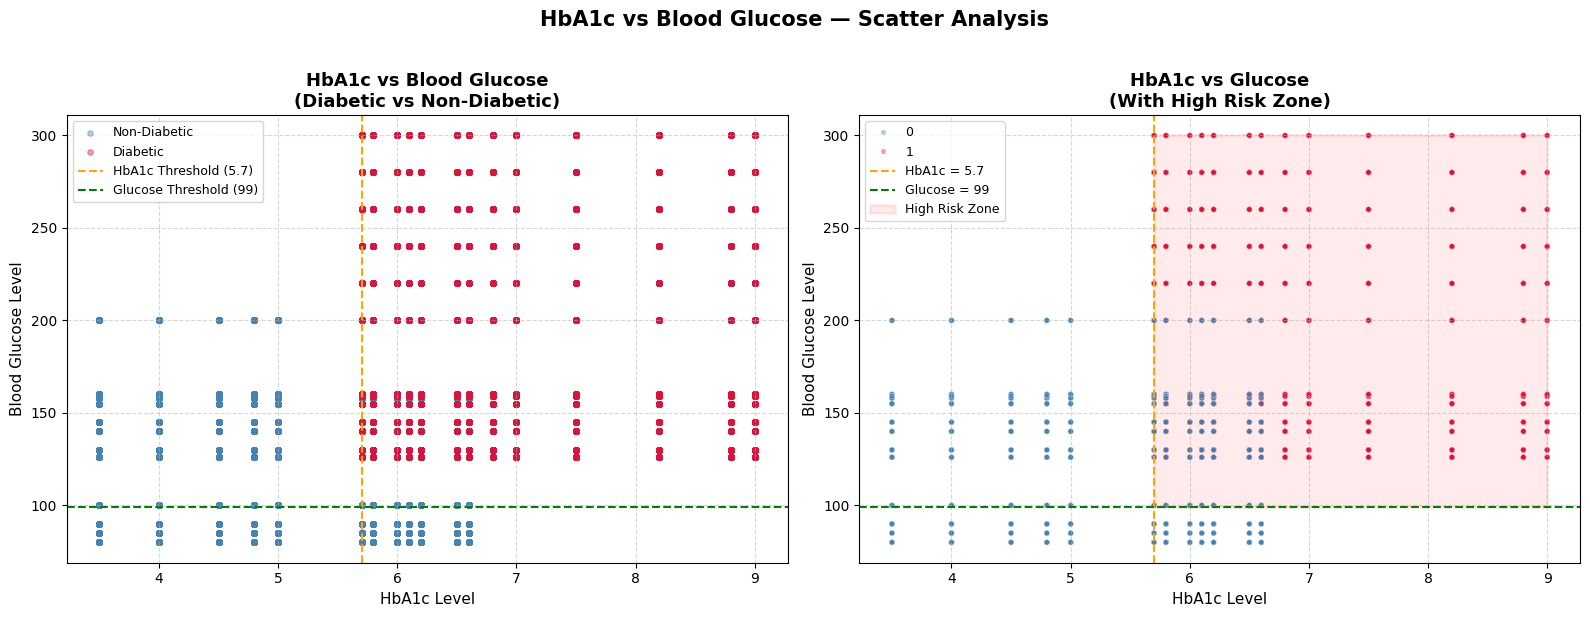

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Simple Scatter ---
colors = {0: 'steelblue', 1: 'crimson'}
for label, group in df.groupby('diabetes'):
    axes[0].scatter(
        group['HbA1c_level'],
        group['blood_glucose_level'],
        c=colors[label],
        label='Diabetic' if label == 1 else 'Non-Diabetic',
        alpha=0.4,
        s=15
    )

# Threshold lines
axes[0].axvline(x=5.7, color='orange', linestyle='--', linewidth=1.5, label='HbA1c Threshold (5.7)')
axes[0].axhline(y=99, color='green', linestyle='--', linewidth=1.5, label='Glucose Threshold (99)')

axes[0].set_title('HbA1c vs Blood Glucose\n(Diabetic vs Non-Diabetic)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('HbA1c Level', fontsize=11)
axes[0].set_ylabel('Blood Glucose Level', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(linestyle='--', alpha=0.5)

# --- Plot 2: Density/KDE Scatter ---
sns.scatterplot(
    data=df,
    x='HbA1c_level',
    y='blood_glucose_level',
    hue='diabetes',
    palette={0: 'steelblue', 1: 'crimson'},
    alpha=0.4,
    s=15,
    ax=axes[1]
)

# Threshold lines
axes[1].axvline(x=5.7, color='orange', linestyle='--', linewidth=1.5, label='HbA1c = 5.7')
axes[1].axhline(y=99, color='green', linestyle='--', linewidth=1.5, label='Glucose = 99')

# Danger Zone Box
from matplotlib.patches import Rectangle
danger_zone = Rectangle(
    (5.7, 99),                    # x, y starting point
    df['HbA1c_level'].max() - 5.7,  # width
    df['blood_glucose_level'].max() - 99,  # height
    linewidth=2,
    edgecolor='red',
    facecolor='red',
    alpha=0.08,
    label='High Risk Zone'
)
axes[1].add_patch(danger_zone)

axes[1].set_title('HbA1c vs Glucose\n(With High Risk Zone)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('HbA1c Level', fontsize=11)
axes[1].set_ylabel('Blood Glucose Level', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(linestyle='--', alpha=0.5)

plt.suptitle('HbA1c vs Blood Glucose — Scatter Analysis',
              fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Key Insight: The scatter plot analysis reveals a highly distinct decision boundary between diabetic and non-diabetic individuals based on medical thresholds. By plotting the intersection of HbA1c $> 5.7$ and Blood Glucose $> 99$, we successfully isolate a "High-Risk Zone" where diabetic cases heavily cluster. This clear spatial separation indicates a very strong non-linear correlation, implying that these two clinical features will likely hold the highest feature importance scores across our machine learning classification models.

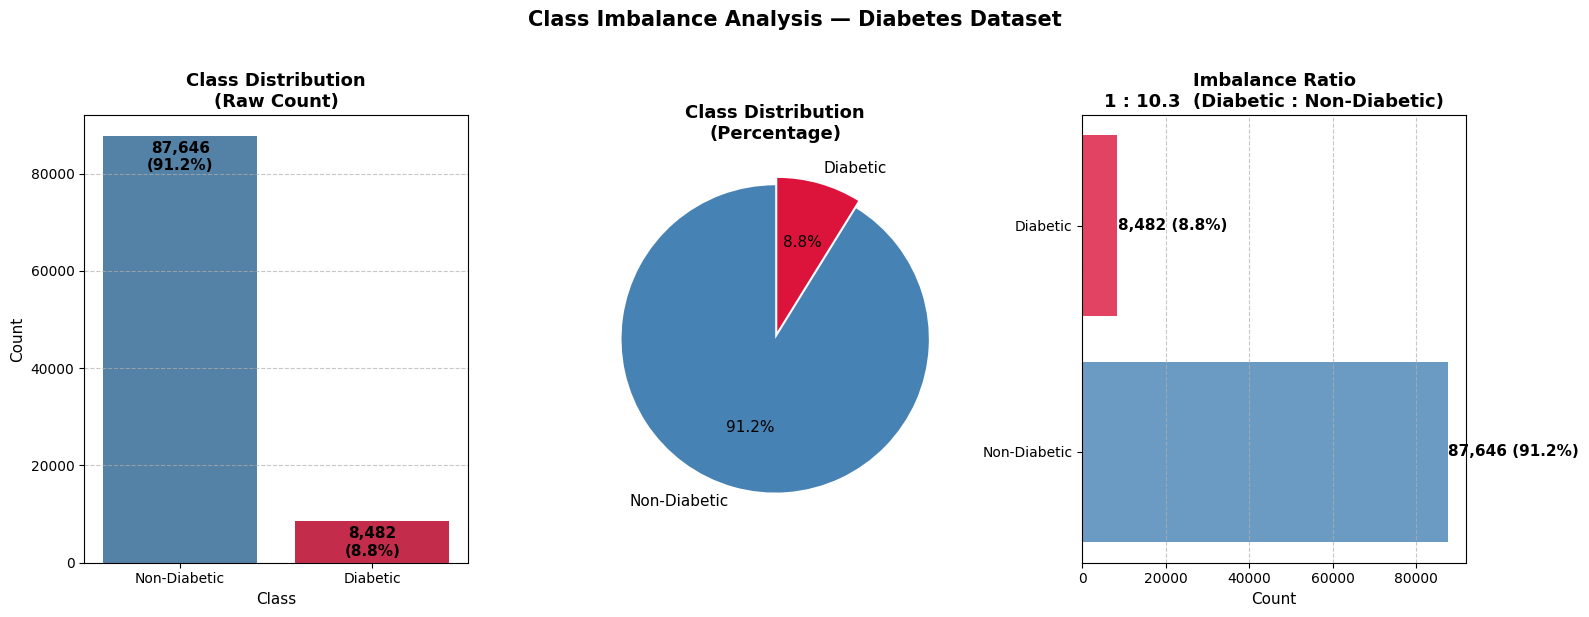

CLASS DISTRIBUTION SUMMARY
Non-Diabetic    → 87,646 (91.2%)
Diabetic        →  8,482 (8.8%)

Imbalance Ratio   → 1 : 10.3
⚠️  HIGH IMBALANCE — SMOTE recommended!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# --- Data Prepare ---
class_counts = df['diabetes'].value_counts().reset_index()
class_counts.columns = ['diabetes', 'count']
class_counts['label'] = class_counts['diabetes'].map({0: 'Non-Diabetic', 1: 'Diabetic'})
class_counts['percentage'] = (class_counts['count'] / class_counts['count'].sum()) * 100

# --- Plot 1: Count Bar Plot ---
sns.barplot(
    data=class_counts,
    x='label', y='count',
    hue='label',
    palette={'Non-Diabetic': 'steelblue', 'Diabetic': 'crimson'},
    ax=axes[0],
    legend=False
)
for i, p in enumerate(axes[0].patches):
    count = class_counts.loc[i, 'count']
    pct = class_counts.loc[i, 'percentage']
    axes[0].annotate(
        f'{count:,}\n({pct:.1f}%)',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, -15),
        textcoords='offset points',
        fontsize=11, fontweight='bold'
    )
axes[0].set_title('Class Distribution\n(Raw Count)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: Pie Chart ---
axes[1].pie(
    class_counts['count'],
    labels=class_counts['label'],
    autopct='%1.1f%%',
    colors=['steelblue', 'crimson'],
    startangle=90,
    explode=(0, 0.05),
    textprops={'fontsize': 11}
)
axes[1].set_title('Class Distribution\n(Percentage)',
                   fontsize=13, fontweight='bold')

# --- Plot 3: Imbalance Ratio Visual ---
ratio = class_counts.loc[class_counts['label'] == 'Non-Diabetic', 'count'].values[0] / \
        class_counts.loc[class_counts['label'] == 'Diabetic', 'count'].values[0]

axes[2].barh(
    ['Non-Diabetic', 'Diabetic'],
    class_counts['count'],
    color=['steelblue', 'crimson'],
    alpha=0.8
)
for i, (count, pct) in enumerate(zip(class_counts['count'], class_counts['percentage'])):
    axes[2].text(
        count + 100, i,
        f'{count:,} ({pct:.1f}%)',
        va='center', fontsize=11, fontweight='bold'
    )
axes[2].set_title(f'Imbalance Ratio\n1 : {ratio:.1f}  (Diabetic : Non-Diabetic)',
                   fontsize=13, fontweight='bold')
axes[2].set_xlabel('Count', fontsize=11)
axes[2].grid(axis='x', linestyle='--', alpha=0.7)

plt.suptitle('Class Imbalance Analysis — Diabetes Dataset',
              fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Console Summary ---
print("=" * 40)
print("CLASS DISTRIBUTION SUMMARY")
print("=" * 40)
for _, row in class_counts.iterrows():
    print(f"{row['label']:<15} → {row['count']:>6,} ({row['percentage']:.1f}%)")
print(f"\nImbalance Ratio   → 1 : {ratio:.1f}")
if ratio > 3:
    print("⚠️  HIGH IMBALANCE — SMOTE recommended!")
elif ratio > 1.5:
    print("⚠️  MODERATE IMBALANCE — class_weight='balanced' use karo")
else:
    print("✅  Balanced Dataset — No action needed")
print("=" * 40)

Key Insight: The target variable exhibits a severe Class Imbalance with a ratio of 1 : 10.3. Non-diabetic records dominate the dataset at 91.2% (87,646 samples), while diabetic records constitute a mere 8.8% (8,482 samples). Standard accuracy will be a misleading metric for this model, as a naive classifier predicting the majority class would achieve 91.2% accuracy while failing to detect actual diabetic cases. To mitigate this risk, we must evaluate the model using F1-Score and Recall (Sensitivity), and apply resampling techniques like SMOTE or adjust algorithmic parameters using class_weight='balanced'.

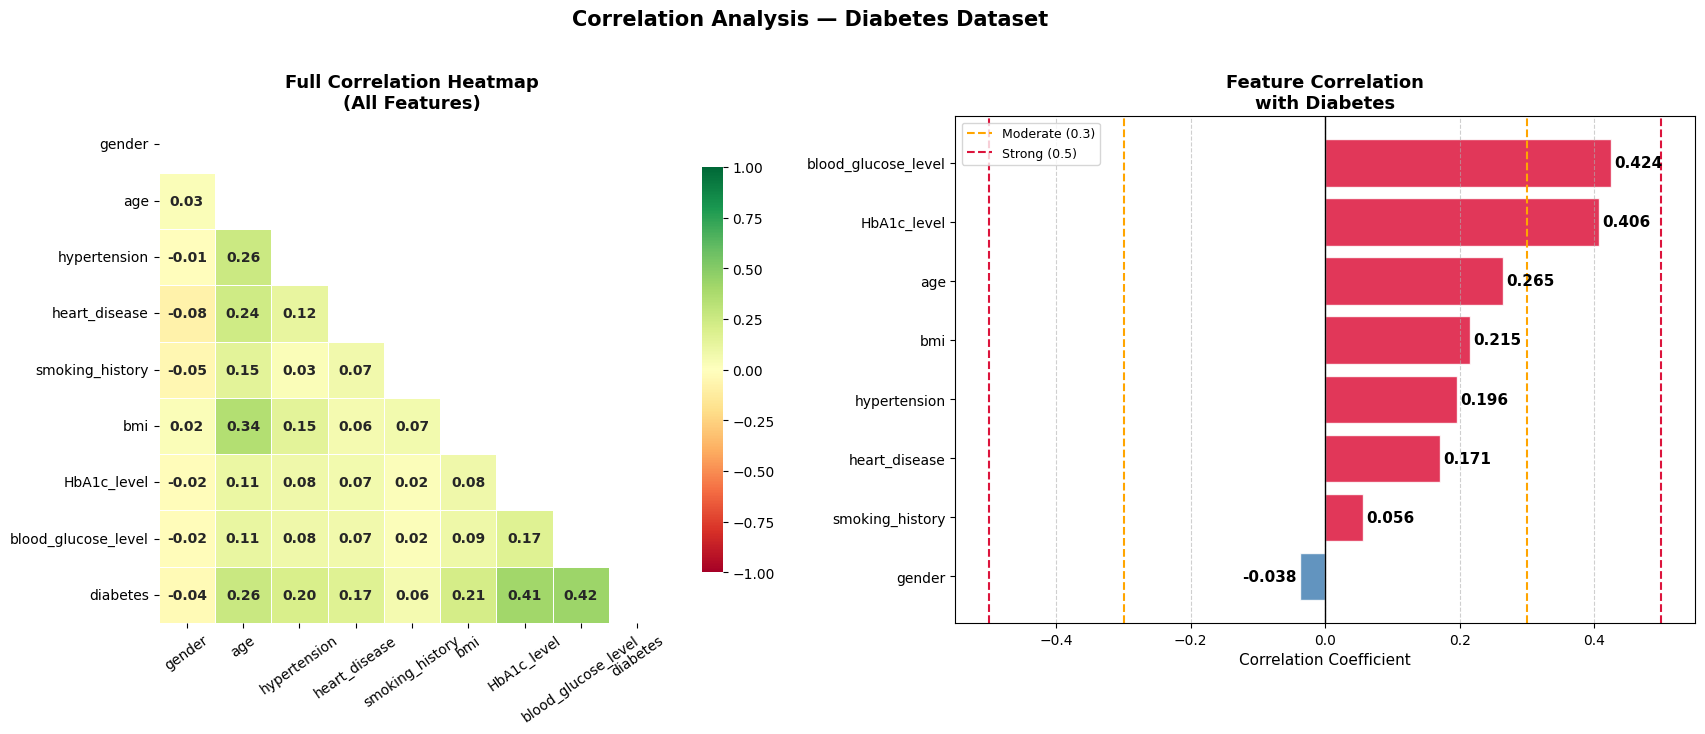

   CORRELATION WITH DIABETES (Sorted)
blood_glucose_level      0.424   🟡 MODERATE
HbA1c_level              0.406   🟡 MODERATE
age                      0.265   🟢 WEAK
bmi                      0.215   🟢 WEAK
hypertension             0.196   🟢 WEAK
heart_disease            0.171   🟢 WEAK
smoking_history          0.056   🟢 WEAK
gender                  -0.038   🟢 WEAK


In [ ]:
# --- Data Prepare ---
df_encoded = df.copy()
df_encoded['gender'] = df_encoded['gender'].map({'Male': 0, 'Female': 1, 'Other': 2})
df_encoded['smoking_history'] = df_encoded['smoking_history'].map({
    'never': 0, 'No Info': 1, 'current': 2,
    'former': 3, 'ever': 4, 'not current': 5
})

# --- Correlation Matrix ---
corr_matrix = df_encoded.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Full Heatmap ---
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # Upper triangle hide karo

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 10, 'weight': 'bold'},
    ax=axes[0],
    square=True,
    cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Full Correlation Heatmap\n(All Features)',
                   fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=35)
axes[0].tick_params(axis='y', rotation=0)

# --- Plot 2: Diabetes ke saath sirf correlation ---
diabetes_corr = corr_matrix['diabetes'].drop('diabetes').sort_values(ascending=False)

colors = ['crimson' if x > 0 else 'steelblue' for x in diabetes_corr]
bars = axes[1].barh(
    diabetes_corr.index[::-1],
    diabetes_corr.values[::-1],
    color=colors[::-1],
    alpha=0.85,
    edgecolor='white'
)
for bar, val in zip(bars, diabetes_corr.values[::-1]):
    axes[1].text(
        val + (0.005 if val >= 0 else -0.005),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=11, fontweight='bold'
    )

axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].axvline(x=0.3,  color='orange', linestyle='--', 
                linewidth=1.5, label='Moderate (0.3)')
axes[1].axvline(x=-0.3, color='orange', linestyle='--', linewidth=1.5)
axes[1].axvline(x=0.5,  color='crimson', linestyle='--', 
                linewidth=1.5, label='Strong (0.5)')
axes[1].axvline(x=-0.5, color='crimson', linestyle='--', linewidth=1.5)

axes[1].set_title('Feature Correlation\nwith Diabetes',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(axis='x', linestyle='--', alpha=0.6)

plt.suptitle('Correlation Analysis — Diabetes Dataset',
              fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Console Summary ---
print("=" * 45)
print("   CORRELATION WITH DIABETES (Sorted)")
print("=" * 45)
for feat, val in diabetes_corr.items():
    if abs(val) >= 0.5:
        strength = "🔴 STRONG"
    elif abs(val) >= 0.3:
        strength = "🟡 MODERATE"
    else:
        strength = "🟢 WEAK"
    print(f"{feat:<22} {val:>7.3f}   {strength}")
print("=" * 45)

Key Insight: Correlation analysis confirms that blood_glucose_level ($0.424$) and HbA1c_level ($0.406$) have the strongest linear relationship with diabetes, making them the primary predictive drivers. Other demographic and clinical factors like age ($0.265$) and bmi ($0.215$) display weaker but positive linear ties. Crucially, the sub-0.3 correlation scores among independent predictors indicate minimal risk of multi-collinearity, proving that each feature brings unique variance to the table. While non-linear tree models will likely exploit deeper interactions, these baseline scores justify prioritizing glucose and HbA1c metrics.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Step 1: Data Prepare ---
df_encoded = df.copy()

# Categorical Encode
df_encoded['gender'] = df_encoded['gender'].map({
    'Male': 0, 'Female': 1, 'Other': 2
})
df_encoded['smoking_history'] = df_encoded['smoking_history'].map({
    'never': 0, 'No Info': 1, 'current': 2,
    'former': 3, 'ever': 4, 'not current': 5
})

# Features aur Target
X = df_encoded.drop('diabetes', axis=1)
y = df_encoded['diabetes']

print("=" * 45)
print("        DATASET SUMMARY")
print("=" * 45)
print(f"Total Samples     : {len(df_encoded):,}")
print(f"Total Features    : {X.shape[1]}")
print(f"Feature Names     : {list(X.columns)}")
print(f"\nClass Distribution:")
print(f"  Non-Diabetic (0): {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)")
print(f"  Diabetic     (1): {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)")
print("=" * 45)

# --- Step 2: Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,
    stratify=y            # ✅ Class ratio maintain karna
)

print("\n")
print("=" * 45)
print("       TRAIN/TEST SPLIT SUMMARY")
print("=" * 45)
print(f"Training Set      : {X_train.shape[0]:,} samples (80%)")
print(f"Testing Set       : {X_test.shape[0]:,} samples (20%)")
print(f"\nTrain Class Distribution:")
print(f"  Non-Diabetic (0): {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")
print(f"  Diabetic     (1): {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)")
print(f"\nTest Class Distribution:")
print(f"  Non-Diabetic (0): {(y_test==0).sum():,} ({(y_test==0).mean()*100:.1f}%)")
print(f"  Diabetic     (1): {(y_test==1).sum():,} ({(y_test==1).mean()*100:.1f}%)")
print("=" * 45)

# --- Step 3: Feature Scaling ---
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # ✅ fit+transform sirf train par
X_test_scaled  = scaler.transform(X_test)         # ✅ sirf transform test par

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("\n")
print("=" * 45)
print("      FEATURE SCALING SUMMARY")
print("=" * 45)
print(f"Scaler Used       : StandardScaler")
print(f"\nBefore Scaling (X_train):")
print(X_train[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']].describe().round(2))
print(f"\nAfter Scaling (X_train_scaled):")
print(X_train_scaled[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']].describe().round(2))
print("=" * 45)
print("\n✅ Train/Test Split aur Feature Scaling Complete!")
print("✅ Agle Step ke liye ready: SMOTE")

        DATASET SUMMARY
Total Samples     : 96,128
Total Features    : 8
Feature Names     : ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']

Class Distribution:
  Non-Diabetic (0): 87,646 (91.2%)
  Diabetic     (1): 8,482 (8.8%)


       TRAIN/TEST SPLIT SUMMARY
Training Set      : 76,902 samples (80%)
Testing Set       : 19,226 samples (20%)

Train Class Distribution:
  Non-Diabetic (0): 70,116 (91.2%)
  Diabetic     (1): 6,786 (8.8%)

Test Class Distribution:
  Non-Diabetic (0): 17,530 (91.2%)
  Diabetic     (1): 1,696 (8.8%)


      FEATURE SCALING SUMMARY
Scaler Used       : StandardScaler

Before Scaling (X_train):
            age       bmi  HbA1c_level  blood_glucose_level
count  76902.00  76902.00     76902.00             76902.00
mean      41.78     27.30         5.53               138.23
std       22.49      6.76         1.07                40.88
min        0.08     10.01         3.50                80.00
25% 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Step 1: Data Prepare ---
# Assuming df is your original DataFrame
df_encoded = df.copy()

# Categorical Encode 'gender'
df_encoded['gender'] = df_encoded['gender'].map({
    'Male': 0, 'Female': 1, 'Other': 2
})

# --- IMPROVEMENT: Use One-Hot Encoding for 'smoking_history' ---
# This creates new columns like 'smoking_never', 'smoking_No Info', etc.
df_encoded = pd.get_dummies(df_encoded, columns=['smoking_history'], prefix='smoking', drop_first=False)
# I have set drop_first=False so that no category is dropped; if you want to avoid multicollinearity,
# you can set drop_first=True, but False is better for interpretability.

# Features and Target
X = df_encoded.drop('diabetes', axis=1)
y = df_encoded['diabetes']

print("=" * 45)
print("        DATASET SUMMARY")
print("=" * 45)
print(f"Total Samples     : {len(df_encoded):,}")
print(f"Total Features    : {X.shape[1]}")
print(f"Feature Names     : {list(X.columns)}")
print(f"\nClass Distribution:")
print(f"  Non-Diabetic (0): {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)")
print(f"  Diabetic     (1): {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)")
print("=" * 45)

# --- Step 2: Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,
    stratify=y            # ✅ Class ratio maintain karna
)

print("\n")
print("=" * 45)
print("       TRAIN/TEST SPLIT SUMMARY")
print("=" * 45)
print(f"Training Set      : {X_train.shape[0]:,} samples (80%)")
print(f"Testing Set       : {X_test.shape[0]:,} samples (20%)")
print(f"\nTrain Class Distribution:")
print(f"  Non-Diabetic (0): {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")
print(f"  Diabetic     (1): {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)")
print(f"\nTest Class Distribution:")
print(f"  Non-Diabetic (0): {(y_test==0).sum():,} ({(y_test==0).mean()*100:.1f}%)")
print(f"  Diabetic     (1): {(y_test==1).sum():,} ({(y_test==1).mean()*100:.1f}%)")
print("=" * 45)

# --- Step 3: Feature Scaling ---
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # ✅ fit+transform sirf train par
X_test_scaled  = scaler.transform(X_test)         # ✅ sirf transform test par

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("\n")
print("=" * 45)
print("      FEATURE SCALING SUMMARY")
print("=" * 45)
print(f"Scaler Used       : StandardScaler")
print(f"\nBefore Scaling (X_train):")
print(X_train[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']].describe().round(2))
print(f"\nAfter Scaling (X_train_scaled):")
print(X_train_scaled[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']].describe().round(2))
print("=" * 45)
print("\n✅ Train/Test Split aur Feature Scaling Complete!")



        DATASET SUMMARY
Total Samples     : 96,128
Total Features    : 13
Feature Names     : ['gender', 'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'smoking_No Info', 'smoking_current', 'smoking_ever', 'smoking_former', 'smoking_never', 'smoking_not current']

Class Distribution:
  Non-Diabetic (0): 87,646 (91.2%)
  Diabetic     (1): 8,482 (8.8%)


       TRAIN/TEST SPLIT SUMMARY
Training Set      : 76,902 samples (80%)
Testing Set       : 19,226 samples (20%)

Train Class Distribution:
  Non-Diabetic (0): 70,116 (91.2%)
  Diabetic     (1): 6,786 (8.8%)

Test Class Distribution:
  Non-Diabetic (0): 17,530 (91.2%)
  Diabetic     (1): 1,696 (8.8%)


      FEATURE SCALING SUMMARY
Scaler Used       : StandardScaler

Before Scaling (X_train):
            age       bmi  HbA1c_level  blood_glucose_level
count  76902.00  76902.00     76902.00             76902.00
mean      41.78     27.30         5.53               138.23
std       22.49      6.76     

         SMOTE SUMMARY
Before SMOTE:
  Non-Diabetic (0): 70,116 (91.2%)
  Diabetic     (1): 6,786 (8.8%)
  Total            : 76,902

After SMOTE:
  Non-Diabetic (0): 70,116 (50.0%)
  Diabetic     (1): 70,116 (50.0%)
  Total            : 140,232

Naye Synthetic Samples: 63,330


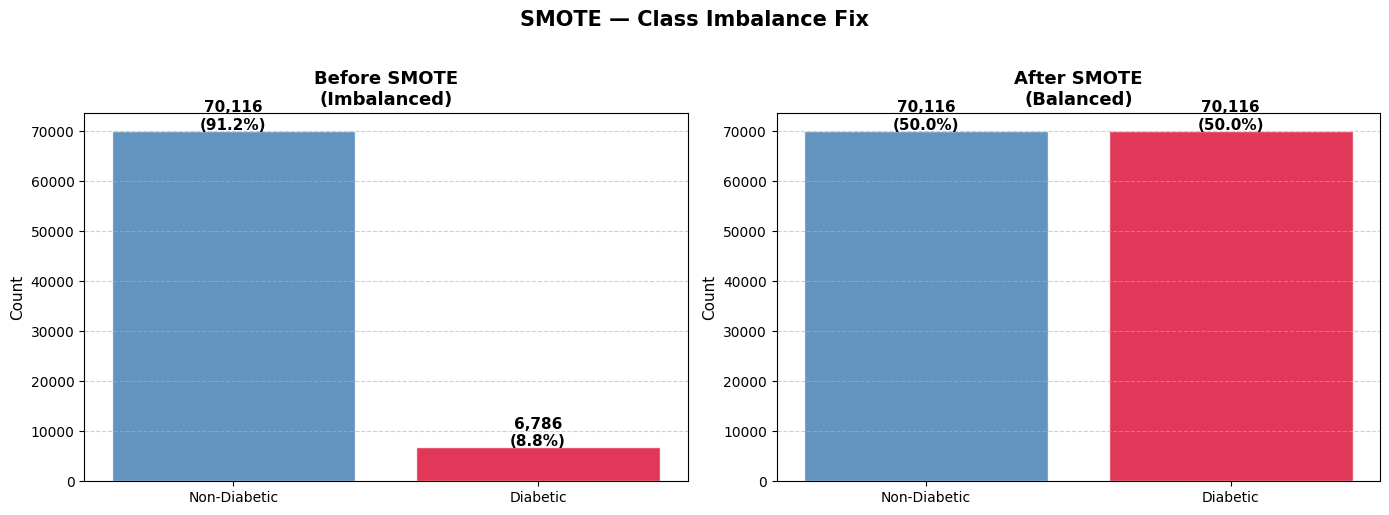


✅ SMOTE Complete!
✅ Agle Step ke liye ready: Model Training


In [ ]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# --- SMOTE Apply ---
smote = SMOTE(
    random_state=42,
    k_neighbors=5        # Default — 5 nearest neighbors
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

# --- Console Summary ---
print("=" * 45)
print("         SMOTE SUMMARY")
print("=" * 45)
print(f"Before SMOTE:")
print(f"  Non-Diabetic (0): {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")
print(f"  Diabetic     (1): {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)")
print(f"  Total            : {len(y_train):,}")
print(f"\nAfter SMOTE:")
print(f"  Non-Diabetic (0): {(y_train_smote==0).sum():,} ({(y_train_smote==0).mean()*100:.1f}%)")
print(f"  Diabetic     (1): {(y_train_smote==1).sum():,} ({(y_train_smote==1).mean()*100:.1f}%)")
print(f"  Total            : {len(y_train_smote):,}")
print(f"\nNaye Synthetic Samples: {(y_train_smote==1).sum() - (y_train==1).sum():,}")
print("=" * 45)

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE
before_counts = [( y_train==0).sum(), (y_train==1).sum()]
axes[0].bar(
    ['Non-Diabetic', 'Diabetic'],
    before_counts,
    color=['steelblue', 'crimson'],
    alpha=0.85,
    edgecolor='white'
)
for i, val in enumerate(before_counts):
    axes[0].text(
        i, val + 200,
        f'{val:,}\n({val/sum(before_counts)*100:.1f}%)',
        ha='center', fontsize=11, fontweight='bold'
    )
axes[0].set_title('Before SMOTE\n(Imbalanced)',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# After SMOTE
after_counts = [(y_train_smote==0).sum(), (y_train_smote==1).sum()]
axes[1].bar(
    ['Non-Diabetic', 'Diabetic'],
    after_counts,
    color=['steelblue', 'crimson'],
    alpha=0.85,
    edgecolor='white'
)
for i, val in enumerate(after_counts):
    axes[1].text(
        i, val + 200,
        f'{val:,}\n({val/sum(after_counts)*100:.1f}%)',
        ha='center', fontsize=11, fontweight='bold'
    )
axes[1].set_title('After SMOTE\n(Balanced)',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('SMOTE — Class Imbalance Fix',
              fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✅ SMOTE Complete!")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                              recall_score, f1_score, roc_auc_score)
import pandas as pd
import time

# --- 8 Models Define ---
models = {
    'Logistic Regression' : LogisticRegression(
                                max_iter=1000, 
                                random_state=42,
                                class_weight='balanced'
                            ),
    'Decision Tree'       : DecisionTreeClassifier(
                                random_state=42,
                                class_weight='balanced',
                                max_depth=10
                            ),
    'Random Forest'       : RandomForestClassifier(
                                n_estimators=100,
                                random_state=42,
                                class_weight='balanced',
                                n_jobs=-1
                            ),
    'XGBoost'             : XGBClassifier(
                                random_state=42,
                                eval_metric='logloss',
                                n_jobs=-1
                            ),
    'SVM'                 : SVC(
                                random_state=42,
                                class_weight='balanced',
                                probability=True    # ROC-AUC ke liye
                            ),
    'KNN'                 : KNeighborsClassifier(
                                n_neighbors=5,
                                n_jobs=-1
                            ),
    'Naive Bayes'         : GaussianNB(),
    'Gradient Boosting'   : GradientBoostingClassifier(
                                random_state=42,
                                n_estimators=100
                            )
}

# --- Training + Evaluation ---
results = []

print("=" * 60)
print("          MODEL TRAINING STARTED")
print("=" * 60)

for name, model in models.items():
    print(f"\n🔄 Training : {name}...")
    
    start = time.time()
    
    # Train
    model.fit(X_train_smote, y_train_smote)
    
    # Predict
    y_pred      = model.predict(X_test_scaled)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Time
    end      = time.time()
    duration = round(end - start, 2)
    
    # Metrics
    acc       = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_pred_prob)
    
    results.append({
        'Model'      : name,
        'Accuracy'   : round(acc * 100, 2),
        'Precision'  : round(precision * 100, 2),
        'Recall'     : round(recall * 100, 2),
        'F1 Score'   : round(f1 * 100, 2),
        'ROC-AUC'    : round(roc_auc * 100, 2),
        'Time (sec)' : duration
    })
    
    print(f"   ✅ Done! | Accuracy: {acc*100:.2f}% | "
          f"F1: {f1*100:.2f}% | "
          f"ROC-AUC: {roc_auc*100:.2f}% | "
          f"Time: {duration}s")

# --- Results Table ---
results_df = pd.DataFrame(results).sort_values(
    'ROC-AUC', ascending=False
).reset_index(drop=True)

results_df.index += 1  # Rank 1 se start

print("\n")
print("=" * 75)
print("                    FINAL RESULTS TABLE")
print("=" * 75)
print(results_df.to_string())
print("=" * 75)

# --- Best Model ---
best_model_name = results_df.iloc[0]['Model']
best_roc        = results_df.iloc[0]['ROC-AUC']
best_f1         = results_df.iloc[0]['F1 Score']

print(f"\n🏆 BEST MODEL  : {best_model_name}")
print(f"   ROC-AUC    : {best_roc}%")
print(f"   F1 Score   : {best_f1}%")
print("=" * 75)